# Лабораторная работа 1

1) Классификация данных методом k ближайших соседей ( kNN)

2) Классификация данных методом опорных векторов (SVM)

3) Построение softmax-классификатора

Вариант 1: задания 1 и 2 на наборе данных CIFAR-10

Вариант 2: задания 1 и 2 на наборе данных MNIST

Вариант 3: задания 1 и 3 на наборе данных CIFAR-10

Вариант 4: задания 1 и 3 на наборе данных MNIST

Лабораторные работы можно выполнять с использованием сервиса Google Colaboratory (https://medium.com/deep-learning-turkey/google-colab-free-gpu-tutorial-e113627b9f5d) или на локальном компьютере. 

## 1. Классификация данных методом k ближайших соседей ( kNN)

In [2]:
import random
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

project_root = os.getcwd()
classifiers_dir = os.path.join(project_root, 'scripts', 'classifiers')

for path in [project_root, classifiers_dir]:
    if path not in sys.path:
        sys.path.insert(0, path)

from scripts.data_utils import load_CIFAR10

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0)
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'


1.1 Скачайте данные в соответсвии с заданием.

CIFAR-10 по ссылке https://www.cs.toronto.edu/~kriz/cifar.html
или используйте  команду !bash get_datasets.sh (google colab, local ubuntu)

MNIST 
sklearn.datasets import load_digits
digits = load_digits()

In [3]:
dataset_paths = [
    'cifar-10-batches-py',
    os.path.join('scripts', 'datasets', 'cifar-10-batches-py')
]

for path in dataset_paths:
    print(path, os.path.isdir(path))


cifar-10-batches-py False
scripts/datasets/cifar-10-batches-py True


In [4]:
dataset_paths = [
    'cifar-10-batches-py',
    os.path.join('scripts', 'datasets', 'cifar-10-batches-py')
]

cifar10_dir = None
for path in dataset_paths:
    if os.path.isdir(path):
        cifar10_dir = path
        break

if cifar10_dir is None:
    raise FileNotFoundError('Не найдена папка cifar-10-batches-py')

try:
   del X_train, y_train
   del X_test, y_test
   print('Clear previously loaded data.')
except:
   pass

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

X_train_raw = X_train.copy()
y_train_raw = y_train.copy()
X_test_raw = X_test.copy()
y_test_raw = y_test.copy()

print('Dataset path: ', cifar10_dir)
print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)


/Users/dispensary/PycharmProjects/LabsAI/lab_1-2/scripts/data_utils.py:15: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return  pickle.load(f, encoding='latin1')


Dataset path:  scripts/datasets/cifar-10-batches-py
Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000,)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000,)


1.2 Выведите несколько примеров изображений из обучающей выборки для каждого класса.



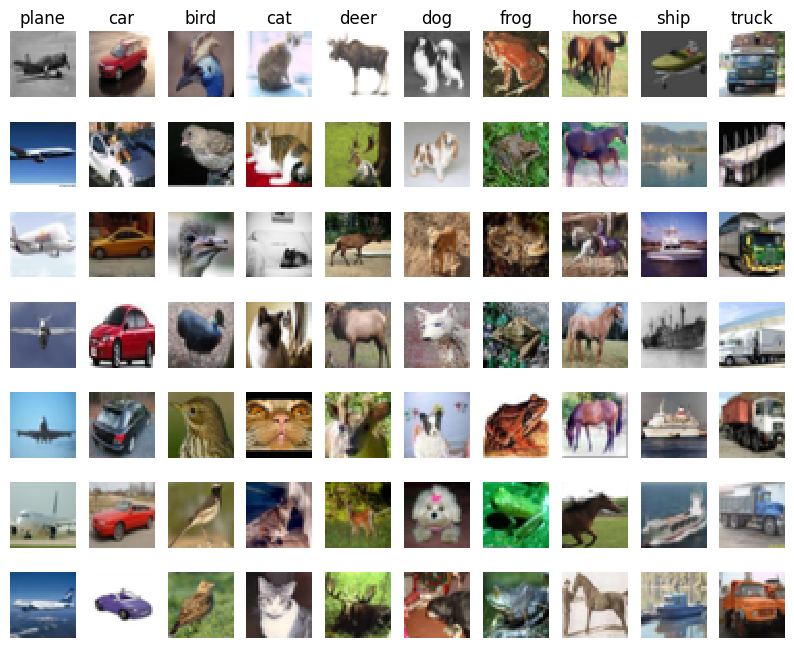

In [5]:
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(classes)
samples_per_class = 7

for y, cls in enumerate(classes):
    idxs = np.flatnonzero(y_train == y)
    idxs = np.random.choice(idxs, samples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + y + 1
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(X_train[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls)
plt.show()


1.3 Разделите данные на обучающу и тестовую выборки (X_train, y_train, X_test, y_test). Преобразуйте каждое изображение в одномерный массив. 

In [6]:
num_training = 5000
num_test = 500

X_train = X_train_raw[:num_training]
y_train = y_train_raw[:num_training]
X_test = X_test_raw[:num_test]
y_test = y_test_raw[:num_test]

X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))

print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)


Training data shape:  (5000, 3072)
Training labels shape:  (5000,)
Test data shape:  (500, 3072)
Test labels shape:  (500,)


1.4 Напишите реализацию классификатора в скрипте /classifiers/k_nearest_neighbor.py и обучите его на сформированной выборке. 

In [7]:
from scripts.classifiers import KNearestNeighbor

classifier = KNearestNeighbor()
classifier.train(X_train, y_train)


1.5 Выполните классификацию на тестовой выборке

In [8]:
dists = classifier.compute_distances_no_loops(X_test)
y_test_pred = classifier.predict_labels(dists, k=1)
print(y_test_pred[:20])
print(y_test[:20])


[4. 9. 8. 8. 4. 4. 3. 2. 5. 8. 2. 8. 5. 7. 2. 2. 5. 3. 1. 4.]
[3 8 8 0 6 6 1 6 3 1 0 9 5 7 9 8 5 7 8 6]


1.6 Визуализируйте матрицу расстояний для каждого изображения из тестовой выборки до изображений из обучающей выборки. 


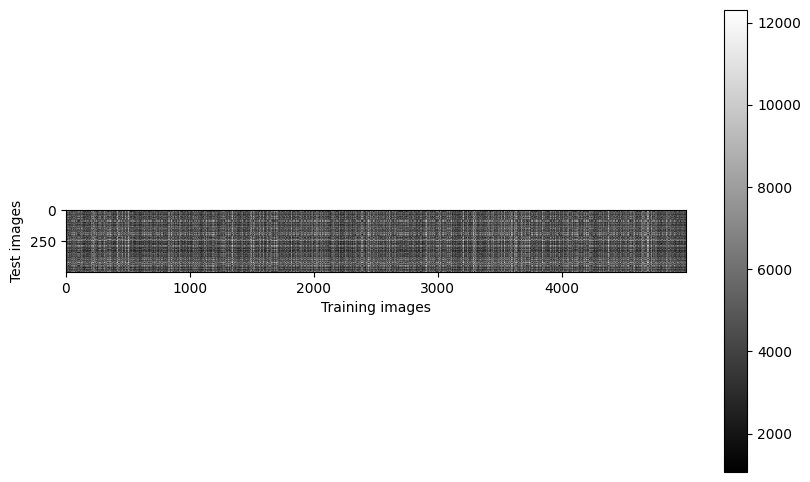

In [9]:
plt.figure(figsize=(10, 6))
plt.imshow(dists, interpolation='none')
plt.xlabel('Training images')
plt.ylabel('Test images')
plt.colorbar()
plt.show()



1.7 Посчитайте долю правильно классифицированных изображений из тестовой выборки.


In [10]:
num_correct = np.sum(y_test_pred == y_test)
accuracy = np.mean(y_test_pred == y_test)

print('Got %d / %d correct => accuracy: %f' % (num_correct, num_test, accuracy))


Got 137 / 500 correct => accuracy: 0.274000


1.8 Постройте график зависимости доли правильно классифицированных изображений от числа соседей, используемых при классификации.

k = 1, accuracy = 0.274000
k = 3, accuracy = 0.272000
k = 5, accuracy = 0.278000
k = 7, accuracy = 0.274000
k = 9, accuracy = 0.268000
k = 11, accuracy = 0.262000
k = 15, accuracy = 0.272000


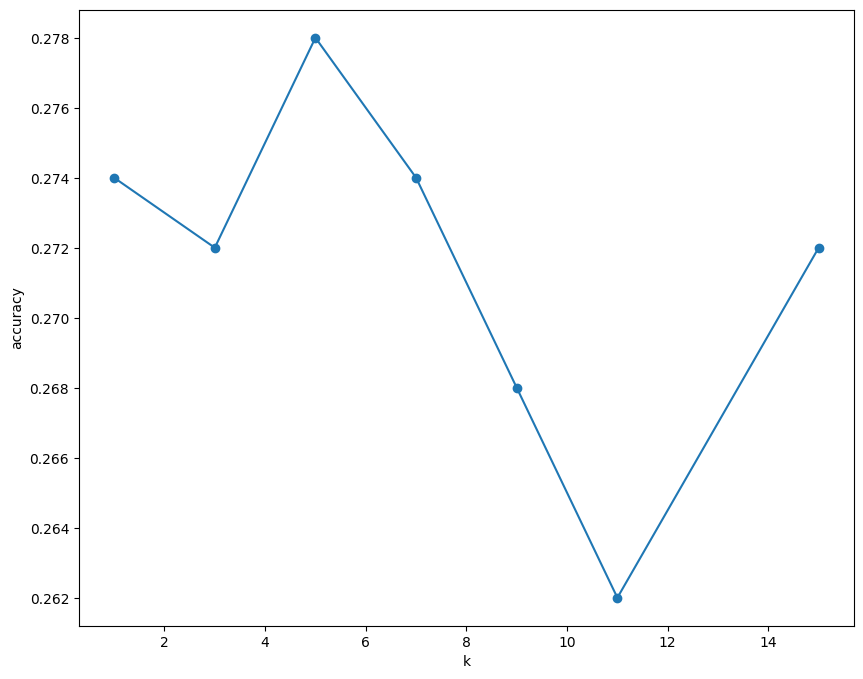

In [11]:
k_choices = [1, 3, 5, 7, 9, 11, 15]
k_accuracies = []

for k in k_choices:
    y_test_pred = classifier.predict_labels(dists, k=k)
    accuracy = np.mean(y_test_pred == y_test)
    k_accuracies.append(accuracy)
    print('k = %d, accuracy = %f' % (k, accuracy))

plt.plot(k_choices, k_accuracies, marker='o')
plt.xlabel('k')
plt.ylabel('accuracy')
plt.show()


1.9 Выберите лучшее значение параметра k на основе кросс-валидации.


k = 1, accuracies = [np.float64(0.263), np.float64(0.257), np.float64(0.264), np.float64(0.278), np.float64(0.266)], mean = 0.265600
k = 3, accuracies = [np.float64(0.239), np.float64(0.249), np.float64(0.24), np.float64(0.266), np.float64(0.254)], mean = 0.249600
k = 5, accuracies = [np.float64(0.248), np.float64(0.266), np.float64(0.28), np.float64(0.292), np.float64(0.28)], mean = 0.273200
k = 8, accuracies = [np.float64(0.262), np.float64(0.282), np.float64(0.273), np.float64(0.29), np.float64(0.273)], mean = 0.276000
k = 10, accuracies = [np.float64(0.265), np.float64(0.296), np.float64(0.276), np.float64(0.284), np.float64(0.28)], mean = 0.280200
k = 12, accuracies = [np.float64(0.26), np.float64(0.295), np.float64(0.279), np.float64(0.283), np.float64(0.28)], mean = 0.279400
k = 15, accuracies = [np.float64(0.252), np.float64(0.289), np.float64(0.278), np.float64(0.282), np.float64(0.274)], mean = 0.275000
k = 20, accuracies = [np.float64(0.27), np.float64(0.279), np.float64(0.2

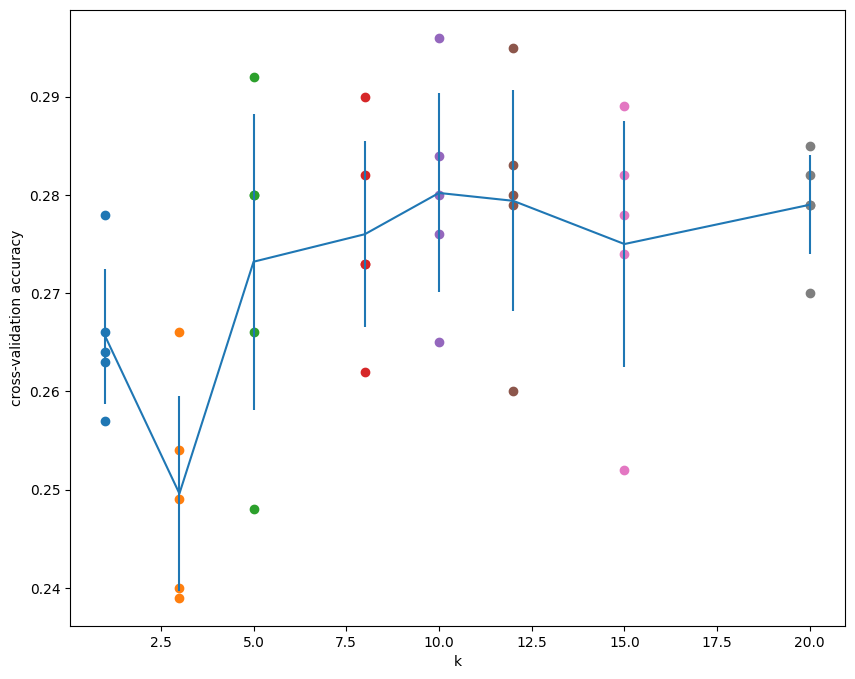

In [12]:
num_folds = 5
k_choices = [1, 3, 5, 8, 10, 12, 15, 20]

X_train_folds = np.array_split(X_train, num_folds)
y_train_folds = np.array_split(y_train, num_folds)

k_to_accuracies = {k: [] for k in k_choices}

for fold_idx in range(num_folds):
    X_val_fold = X_train_folds[fold_idx]
    y_val_fold = y_train_folds[fold_idx]
    X_train_fold = np.concatenate([X_train_folds[i] for i in range(num_folds) if i != fold_idx])
    y_train_fold = np.concatenate([y_train_folds[i] for i in range(num_folds) if i != fold_idx])

    classifier = KNearestNeighbor()
    classifier.train(X_train_fold, y_train_fold)
    dists_fold = classifier.compute_distances_no_loops(X_val_fold)

    for k in k_choices:
        y_val_pred = classifier.predict_labels(dists_fold, k=k)
        accuracy = np.mean(y_val_pred == y_val_fold)
        k_to_accuracies[k].append(accuracy)

for k in k_choices:
    accuracies = k_to_accuracies[k]
    print('k = %d, accuracies = %s, mean = %f' % (k, accuracies, np.mean(accuracies)))

best_k = max(k_choices, key=lambda k: np.mean(k_to_accuracies[k]))
print('best k: ', best_k)

for k in k_choices:
    accuracies = k_to_accuracies[k]
    plt.scatter([k] * len(accuracies), accuracies)

accuracies_mean = np.array([np.mean(k_to_accuracies[k]) for k in k_choices])
accuracies_std = np.array([np.std(k_to_accuracies[k]) for k in k_choices])

plt.errorbar(k_choices, accuracies_mean, yerr=accuracies_std)
plt.xlabel('k')
plt.ylabel('cross-validation accuracy')
plt.show()



1.10 Переобучите и протестируйте классификатор с использованием выбранного значения k.



In [13]:
classifier = KNearestNeighbor()
classifier.train(X_train, y_train)

dists_test = classifier.compute_distances_no_loops(X_test)
y_test_pred = classifier.predict_labels(dists_test, k=best_k)
test_accuracy = np.mean(y_test_pred == y_test)

print('best k: ', best_k)
print('test accuracy: %f' % test_accuracy)


best k:  10
test accuracy: 0.282000


1.11 Сделайте выводы по результатам 1 части задания.

В первой части я реализовал классификатор k ближайших соседей для CIFAR-10. При k = 1 accuracy на тестовой выборке составила 0.274000. После проверки разных значений k и кросс-валидации лучшим оказалось значение k = 10, при котором итоговая accuracy на тестовой выборке составила 0.282000. Я сделал вывод, что увеличение k не всегда улучшает качество: при малом k классификатор слишком сильно зависит от отдельных объектов, а при большом k учитывает больше нерелевантных соседей. Для CIFAR-10 метод kNN показывает ограниченное качество, потому что сравнивает изображения по пиксельным расстояниям и не выделяет содержательные признаки объектов.

## 2.  Классификация данных методом опорных векторов (SVM)

2.1 Разделите данные на обучающую, тестовую и валидационную выборки. Преобразуйте каждое изображение в одномерный массив. Выведите размеры выборок.

In [14]:
num_training = 49000
num_validation = 1000
num_test = 1000
num_dev = 500

X_train = X_train_raw[:num_training]
y_train = y_train_raw[:num_training]

X_val = X_train_raw[num_training:num_training + num_validation]
y_val = y_train_raw[num_training:num_training + num_validation]

X_test = X_test_raw[:num_test]
y_test = y_test_raw[:num_test]

mask = np.random.choice(num_training, num_dev, replace=False)
X_dev = X_train[mask]
y_dev = y_train[mask]

X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_val = np.reshape(X_val, (X_val.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))
X_dev = np.reshape(X_dev, (X_dev.shape[0], -1))

print('Train data shape: ', X_train.shape)
print('Train labels shape: ', y_train.shape)
print('Validation data shape: ', X_val.shape)
print('Validation labels shape: ', y_val.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)
print('Dev data shape: ', X_dev.shape)
print('Dev labels shape: ', y_dev.shape)


Train data shape:  (49000, 3072)
Train labels shape:  (49000,)
Validation data shape:  (1000, 3072)
Validation labels shape:  (1000,)
Test data shape:  (1000, 3072)
Test labels shape:  (1000,)
Dev data shape:  (500, 3072)
Dev labels shape:  (500,)


2.2 Проведите предварительную обработку данных, путем вычитания среднего изображения, рассчитанного  по обучающей выборке.

2.3 Чтобы далее не учитывать смещение (свободный член b), добавьте дополнитульную размерность к массиву дынных и заполните ее 1.

[130.64189796 135.98173469 132.47391837 130.05569388 135.34804082
 131.75402041 130.96055102 136.14328571 132.47636735 131.48467347]


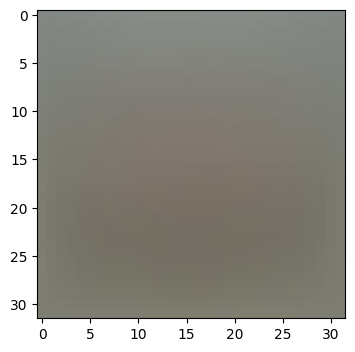

(49000, 3073) (1000, 3073) (1000, 3073) (500, 3073)


In [15]:
mean_image = np.mean(X_train, axis=0)
print(mean_image[:10])
plt.figure(figsize=(4, 4))
plt.imshow(mean_image.reshape((32, 32, 3)).astype('uint8'))
plt.show()

X_train -= mean_image
X_val -= mean_image
X_test -= mean_image
X_dev -= mean_image

X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
X_dev = np.hstack([X_dev, np.ones((X_dev.shape[0], 1))])

print(X_train.shape, X_val.shape, X_test.shape, X_dev.shape)


2.4 Реализуйте loss-функции в scripts/classifiers/linear_svm.py



In [16]:
from scripts.classifiers.linear_svm import svm_loss_naive, svm_loss_vectorized
import time

W = np.random.randn(X_train.shape[1], 10) * 0.0001

loss, grad = svm_loss_naive(W, X_dev, y_dev, 0.000005)
print('loss: %f' % (loss, ))


loss: 8.826885



2.5 Убедитесь, что вы верно реализовали расчет градиента, сравнив с реализацией численными методами (код приведен ниже).

In [17]:

loss, grad = svm_loss_naive(W, X_dev, y_dev, 0.0)

from scripts.gradient_check import grad_check_sparse
f = lambda w: svm_loss_naive(w, X_dev, y_dev, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad)


loss, grad = svm_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: svm_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad)


numerical: -11.637916 analytic: -11.637916, relative error: 8.509724e-12
numerical: -44.887052 analytic: -44.887052, relative error: 6.917839e-12
numerical: -16.063450 analytic: -16.063450, relative error: 1.007529e-12
numerical: 9.736627 analytic: 9.736627, relative error: 4.288177e-12
numerical: -31.894862 analytic: -31.894862, relative error: 1.863526e-12
numerical: -17.268740 analytic: -17.268740, relative error: 2.147214e-11
numerical: 2.904541 analytic: 2.904541, relative error: 7.298319e-11
numerical: -16.885547 analytic: -16.885547, relative error: 4.007062e-13
numerical: -2.319728 analytic: -2.319728, relative error: 1.148209e-10
numerical: -38.045724 analytic: -38.045724, relative error: 1.297517e-12
numerical: -10.613985 analytic: -10.613985, relative error: 4.556645e-11
numerical: 22.235184 analytic: 22.235184, relative error: 7.172396e-12
numerical: -41.229958 analytic: -41.229958, relative error: 2.051408e-12
numerical: -16.344904 analytic: -16.344904, relative error: 1.4

2.6 Сравните svm_loss_naive и svm_loss_vectorized реализации

In [18]:
tic = time.time()
_, grad_naive = svm_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Naive loss and gradient: computed in %fs' % (toc - tic))

tic = time.time()
_, grad_vectorized = svm_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Vectorized loss and gradient: computed in %fs' % (toc - tic))

difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
print('difference: %f' % difference)


Naive loss and gradient: computed in 0.053803s
Vectorized loss and gradient: computed in 0.002803s
difference: 0.000000


2.7 Реализуйте стохастический градиентный спуск в /classifiers/linear_classifier.py . Реализуйте методы train() и predict() и запустите следующий код

In [19]:
from scripts.classifiers import LinearSVM
svm = LinearSVM()
tic = time.time()
loss_hist = svm.train(X_train, y_train, learning_rate=1e-7, reg=2.5e4,
                      num_iters=1500, verbose=True)
toc = time.time()
print('That took %fs' % (toc - tic))


iteration 0 / 1500: loss 781.817058
iteration 100 / 1500: loss 284.910067
iteration 200 / 1500: loss 107.408320
iteration 300 / 1500: loss 41.524928
iteration 400 / 1500: loss 19.273135
iteration 500 / 1500: loss 10.969941
iteration 600 / 1500: loss 7.121153
iteration 700 / 1500: loss 6.534991
iteration 800 / 1500: loss 5.657683
iteration 900 / 1500: loss 5.855275
iteration 1000 / 1500: loss 5.088980
iteration 1100 / 1500: loss 5.378588
iteration 1200 / 1500: loss 5.038356
iteration 1300 / 1500: loss 5.106055
iteration 1400 / 1500: loss 5.868580
That took 2.216926s


In [20]:
y_train_pred = svm.predict(X_train)
print('training accuracy: %f' % (np.mean(y_train == y_train_pred), ))
y_val_pred = svm.predict(X_val)
print('validation accuracy: %f' % (np.mean(y_val == y_val_pred), ))


training accuracy: 0.369776
validation accuracy: 0.389000


2.8 С помощью кросс-валидации выберите значения параметров скорости обучения и регуляризации. В кросс-валидации используйте обучающую и валидационную выборки. Оцените accuracy на тестовой выборке.

In [21]:
from scripts.classifiers import LinearSVM

learning_rates = [1e-7, 2e-7, 5e-7, 1e-6]
regularization_strengths = [2.5e4, 5e4, 1e5]

results = {}
best_val = -1
best_svm = None
best_params = None

for learning_rate in learning_rates:
    for regularization_strength in regularization_strengths:
        svm = LinearSVM()
        svm.train(
            X_train,
            y_train,
            learning_rate=learning_rate,
            reg=regularization_strength,
            num_iters=1000,
            batch_size=200,
            verbose=False
        )

        y_train_pred = svm.predict(X_train)
        train_accuracy = np.mean(y_train == y_train_pred)

        y_val_pred = svm.predict(X_val)
        val_accuracy = np.mean(y_val == y_val_pred)

        results[(learning_rate, regularization_strength)] = (train_accuracy, val_accuracy)

        if val_accuracy > best_val:
            best_val = val_accuracy
            best_svm = svm
            best_params = (learning_rate, regularization_strength)

for learning_rate, regularization_strength in sorted(results):
    train_accuracy, val_accuracy = results[(learning_rate, regularization_strength)]
    print('lr %e reg %e train accuracy: %f val accuracy: %f' % (
        learning_rate,
        regularization_strength,
        train_accuracy,
        val_accuracy
    ))

print('best validation accuracy achieved during cross-validation: %f' % best_val)
print('best learning_rate: %e, best regularization_strength: %e' % best_params)

y_test_pred = best_svm.predict(X_test)
test_accuracy = np.mean(y_test == y_test_pred)
print('linear SVM on raw pixels final test set accuracy: %f' % test_accuracy)


lr 1.000000e-07 reg 2.500000e+04 train accuracy: 0.365571 val accuracy: 0.380000
lr 1.000000e-07 reg 5.000000e+04 train accuracy: 0.352000 val accuracy: 0.368000
lr 1.000000e-07 reg 1.000000e+05 train accuracy: 0.342061 val accuracy: 0.359000
lr 2.000000e-07 reg 2.500000e+04 train accuracy: 0.367939 val accuracy: 0.370000
lr 2.000000e-07 reg 5.000000e+04 train accuracy: 0.352265 val accuracy: 0.350000
lr 2.000000e-07 reg 1.000000e+05 train accuracy: 0.335020 val accuracy: 0.344000
lr 5.000000e-07 reg 2.500000e+04 train accuracy: 0.346776 val accuracy: 0.353000
lr 5.000000e-07 reg 5.000000e+04 train accuracy: 0.295673 val accuracy: 0.313000
lr 5.000000e-07 reg 1.000000e+05 train accuracy: 0.281265 val accuracy: 0.283000
lr 1.000000e-06 reg 2.500000e+04 train accuracy: 0.269449 val accuracy: 0.301000
lr 1.000000e-06 reg 5.000000e+04 train accuracy: 0.280878 val accuracy: 0.277000
lr 1.000000e-06 reg 1.000000e+05 train accuracy: 0.241020 val accuracy: 0.260000
best validation accuracy ach

2.9 Сделайте выводы по второй части задания

Во второй части я реализовал SVM-классификатор и проверил корректность градиента с помощью численной проверки. Значения численного и аналитического градиента практически совпали, поэтому реализация градиента корректна. Векторизованная реализация дала тот же результат, что и наивная, но работала быстрее. После подбора скорости обучения и коэффициента регуляризации лучшими параметрами стали learning_rate = 1e-07 и regularization_strength = 2.5e+04. Лучшая accuracy на валидационной выборке составила 0.380000, а итоговая accuracy на тестовой выборке составила 0.363000. Я сделал вывод, что SVM лучше подходит для этой задачи, чем kNN, потому что он обучает веса признаков, а не просто сравнивает изображения по расстоянию между пикселями.